In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

In [2]:
data = pd.read_csv("summary-data.csv")

In [5]:
data.describe()

,AnnualIncome,HouseholdSize,YrsEdAfterHS,HrWkTV,AnnualCharges
count,100.000000,100.00000,100.000000,100.000000,100.000000
mean,67.248000,4.57000,2.640000,29.140000,11499.524900
std,28.529809,2.06586,1.560368,16.605962,6227.223809
min,15.900000,1.00000,0.000000,2.000000,0.000000
25%,45.250000,3.00000,1.750000,16.000000,7635.727500
50%,66.600000,5.00000,3.000000,27.000000,10956.480000
75%,90.300000,6.00000,4.000000,43.000000,16047.270000
max,126.900000,8.00000,5.000000,60.000000,25181.640000


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   AnnualIncome   100 non-null    float64
 1   HouseholdSize  100 non-null    int64  
 2   YrsEdAfterHS   100 non-null    int64  
 3   HrWkTV         100 non-null    int64  
 4   AnnualCharges  100 non-null    float64
dtypes: float64(2), int64(3)
memory usage: 4.0 KB


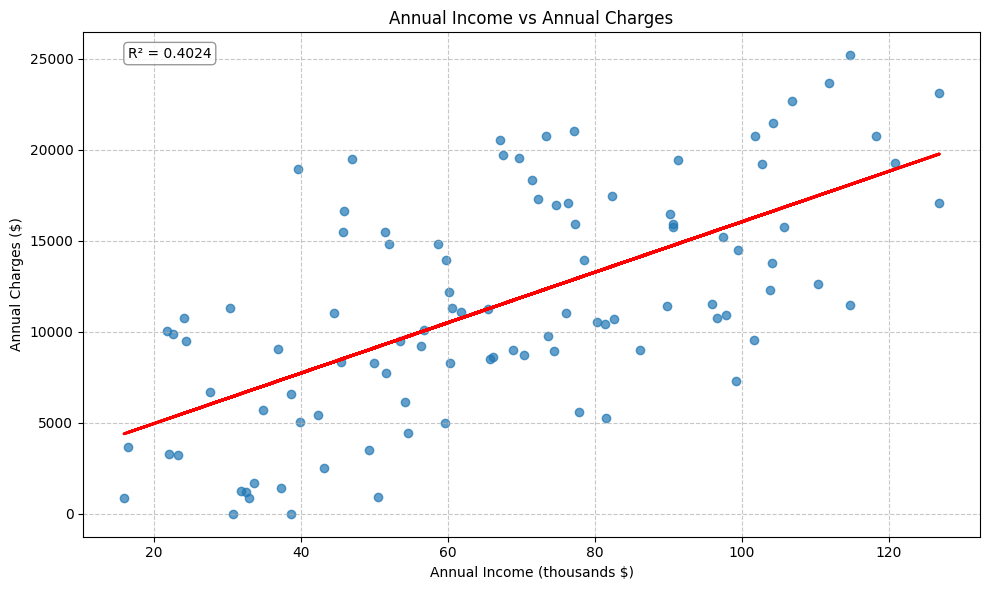

In [7]:
plt.figure(figsize=(10, 6))
plt.scatter(data['AnnualIncome'], data['AnnualCharges'], alpha=0.7)
plt.title('Annual Income vs Annual Charges')
plt.xlabel('Annual Income (thousands $)')
plt.ylabel('Annual Charges ($)')
plt.grid(True, linestyle='--', alpha=0.7)


x = data['AnnualIncome'].values.reshape(-1, 1)
y = data['AnnualCharges'].values
model = LinearRegression()
model.fit(x, y)
plt.plot(x, model.predict(x), color='red', linewidth=2)


r2 = r2_score(y, model.predict(x))
plt.annotate(f'R² = {r2:.4f}', xy=(0.05, 0.95), xycoords='axes fraction',
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))

plt.tight_layout()
plt.savefig('income_vs_charges.png')


In [8]:
X = data['AnnualIncome'].values.reshape(-1, 1)
y = data['AnnualCharges'].values

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [11]:
y_pred = model.predict(X_test)

In [12]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n--- Task 2: Simple Linear Regression Model ---")
print(f"Intercept: {model.intercept_:.4f}")
print(f"Coefficient for Annual Income: {model.coef_[0]:.4f}")
print(f"Mean Squared Error: {mse:.4f}")
print(f"R-squared: {r2:.4f}")
print(f"Equation: Annual Charges = {model.intercept_:.2f} + {model.coef_[0]:.2f} × Annual Income")


--- Task 2: Simple Linear Regression Model ---
Intercept: 2095.4699
Coefficient for Annual Income: 135.4137
Mean Squared Error: 25736945.8926
R-squared: 0.4491
Equation: Annual Charges = 2095.47 + 135.41 × Annual Income


In [13]:
correlation_matrix = data.corr()
print("\nCorrelation Matrix:")
print(correlation_matrix['AnnualCharges'].sort_values(ascending=False))


Correlation Matrix:
AnnualCharges    1.000000
AnnualIncome     0.634329
HouseholdSize    0.221690
HrWkTV           0.115820
YrsEdAfterHS    -0.023833
Name: AnnualCharges, dtype: float64


In [14]:
X_multi = data[['AnnualIncome', 'HouseholdSize', 'YrsEdAfterHS', 'HrWkTV']]
y = data['AnnualCharges'].values

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X_multi, y, test_size=0.2, random_state=40)

In [35]:
multi_model = LinearRegression()
multi_model.fit(X_train, y_train)

LinearRegression()

In [36]:
y_pred_multi = multi_model.predict(X_test)

In [37]:
mse_multi = mean_squared_error(y_test, y_pred_multi)
r2_multi = r2_score(y_test, y_pred_multi)

print("\n--- Task 3: Multiple Linear Regression Model ---")
print(f"Intercept: {multi_model.intercept_:.4f}")
print("Coefficients:")
for i, col in enumerate(X_multi.columns):
    print(f"  {col}: {multi_model.coef_[i]:.4f}")
print(f"Mean Squared Error: {mse_multi:.4f}")
print(f"R-squared: {r2_multi:.4f}")


--- Task 3: Multiple Linear Regression Model ---
Intercept: 886.0380
Coefficients:
  AnnualIncome: 128.2698
  HouseholdSize: 520.8074
  YrsEdAfterHS: -270.7752
  HrWkTV: 26.5706
Mean Squared Error: 19569610.3544
R-squared: 0.5073


<Figure size 1200x1000 with 0 Axes>

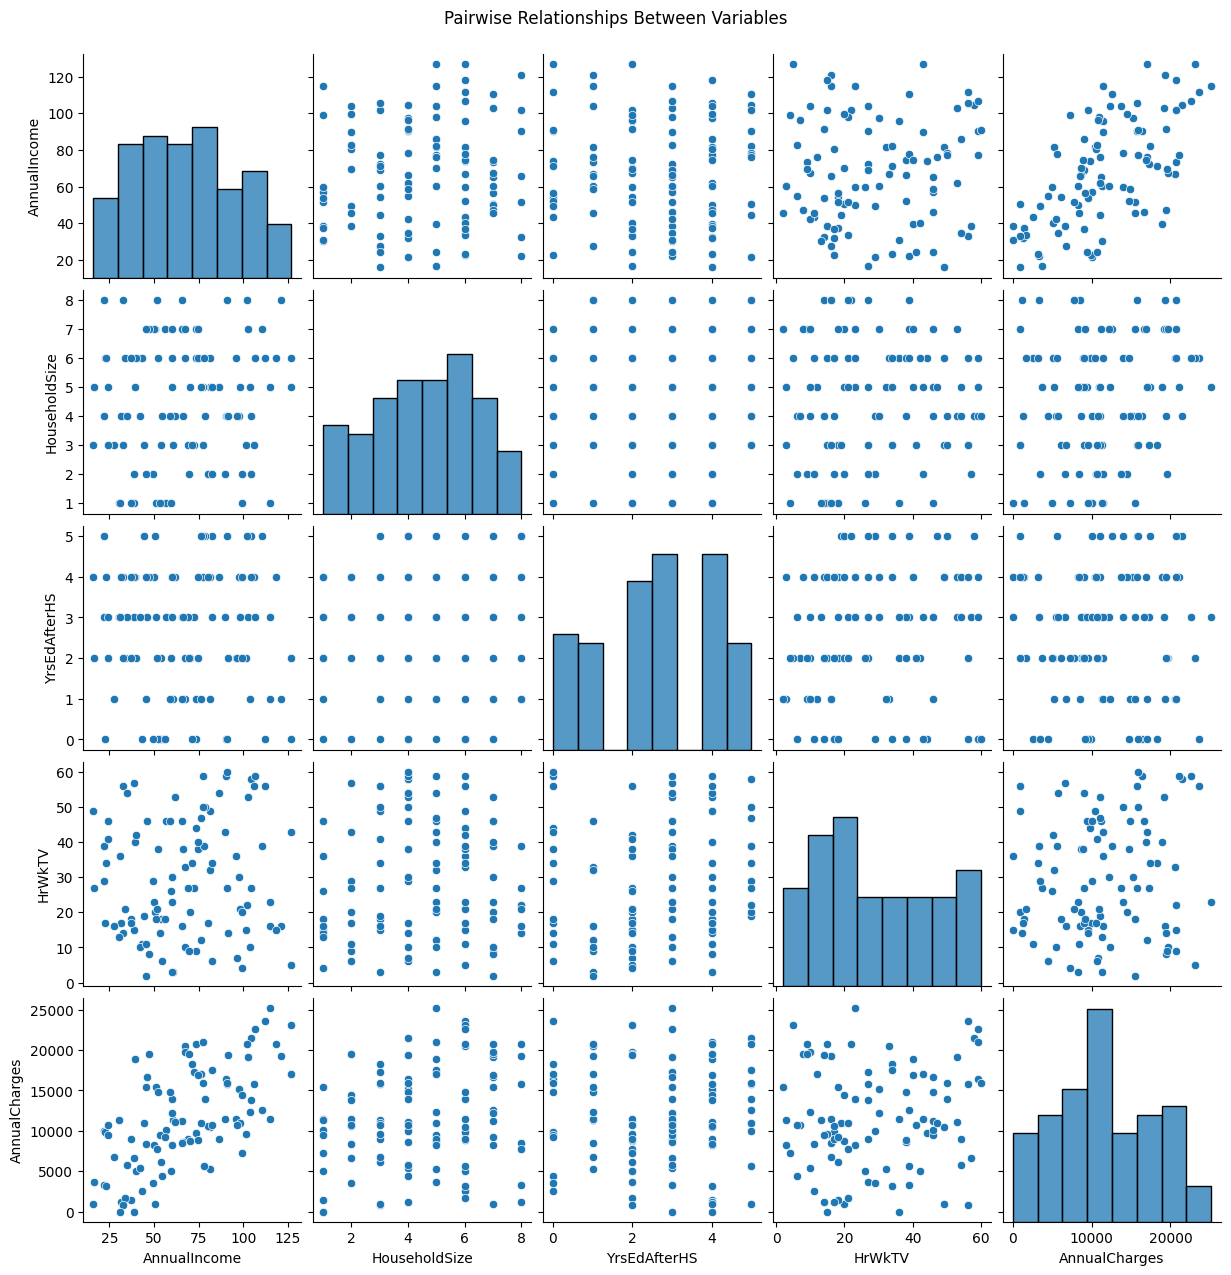

In [39]:
plt.figure(figsize=(12, 10))
sns.pairplot(data, vars=['AnnualIncome', 'HouseholdSize', 'YrsEdAfterHS', 'HrWkTV', 'AnnualCharges'])
plt.suptitle('Pairwise Relationships Between Variables', y=1.02)
plt.savefig('pairplot.png')

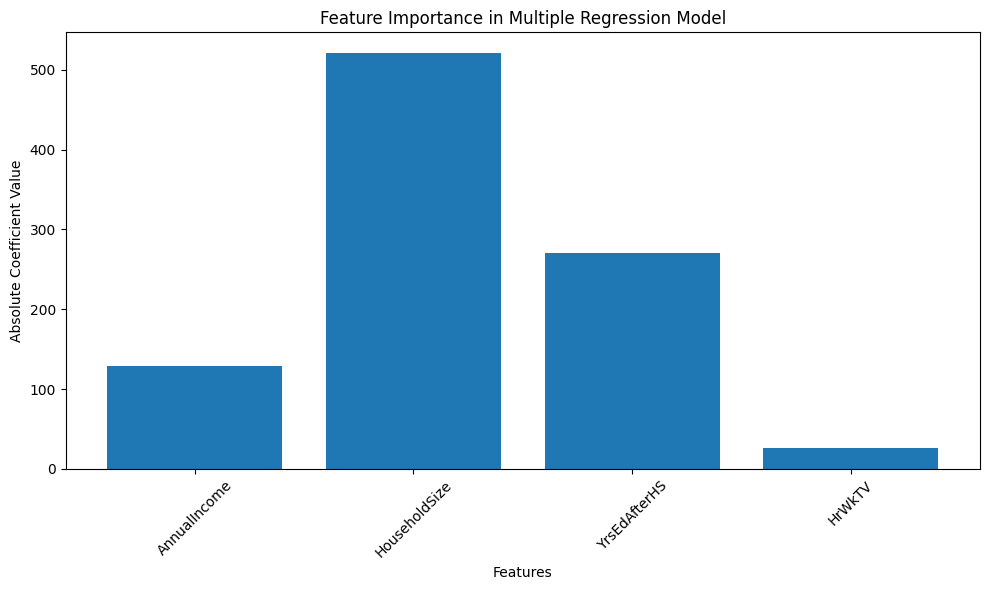

In [23]:
plt.figure(figsize=(10, 6))
importance = abs(multi_model.coef_)
plt.bar(X_multi.columns, importance)
plt.title('Feature Importance in Multiple Regression Model')
plt.xlabel('Features')
plt.ylabel('Absolute Coefficient Value')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('feature_importance.png')

In [ ]:
y_pred_train = multi_model.predict(X_train)
residuals = y_train - y_pred_train

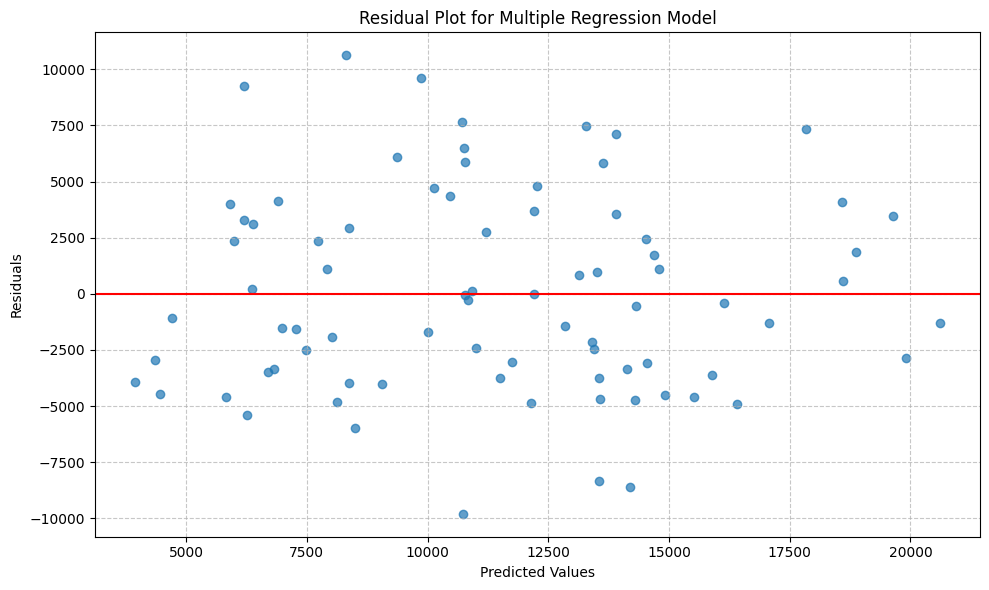

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(y_pred_train, residuals, alpha=0.7)
plt.axhline(y=0, color='r', linestyle='-')
plt.title('Residual Plot for Multiple Regression Model')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('residual_plot.png')